<a href="https://colab.research.google.com/github/snehaxavier2110/Mtech_coursework/blob/main/sarimax_delhi_air_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
data = pd.read_csv('/content/delhi (1).csv')
data

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,01-01-2015,Delhi,296.825,560.235,69.16,36.39,110.59,33.85,3.31,9.25,41.68,8.895,24.86,472.0,Severe
1,02-01-2015,Delhi,186.180,269.550,62.09,32.87,88.14,31.83,3.31,6.65,29.97,8.895,20.09,454.0,Severe
2,03-01-2015,Delhi,87.180,131.900,25.73,30.31,47.95,69.55,3.31,2.65,19.71,3.910,10.23,143.0,Moderate
3,04-01-2015,Delhi,151.840,241.840,25.01,36.91,48.62,74.87,3.31,4.63,25.36,4.260,9.71,319.0,Very Poor
4,05-01-2015,Delhi,146.600,219.130,14.01,34.92,38.25,74.87,3.31,3.33,23.20,2.800,6.21,325.0,Very Poor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2004,27-06-2020,Delhi,39.800,155.940,10.88,21.46,22.47,31.43,0.87,10.38,18.88,1.690,19.99,112.0,Moderate
2005,28-06-2020,Delhi,59.520,308.650,12.67,21.60,23.86,29.27,0.94,10.70,18.05,1.710,25.13,196.0,Moderate
2006,29-06-2020,Delhi,44.860,184.120,10.50,21.57,21.94,27.97,0.88,11.58,26.61,2.130,23.80,233.0,Poor
2007,30-06-2020,Delhi,39.800,91.980,5.99,17.96,15.44,28.48,0.84,10.51,37.29,1.570,16.37,114.0,Moderate


In [ ]:
data.tail()

,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
2004,27-06-2020,Delhi,39.80,155.94,10.88,21.46,22.47,31.43,0.87,10.38,18.88,1.69,19.99,112.0,Moderate
2005,28-06-2020,Delhi,59.52,308.65,12.67,21.60,23.86,29.27,0.94,10.70,18.05,1.71,25.13,196.0,Moderate
2006,29-06-2020,Delhi,44.86,184.12,10.50,21.57,21.94,27.97,0.88,11.58,26.61,2.13,23.80,233.0,Poor
2007,30-06-2020,Delhi,39.80,91.98,5.99,17.96,15.44,28.48,0.84,10.51,37.29,1.57,16.37,114.0,Moderate
2008,01-07-2020,Delhi,54.01,128.66,6.33,21.05,16.81,29.06,0.97,11.15,29.73,2.03,23.57,101.0,Moderate


In [ ]:
# Basic info about the dataset
print("Shape of the dataset:", data.shape)
print("\nData types and non-null counts:")
print(data.info())

# Summary statistics for numerical columns
print("\nSummary statistics:")
print(data.describe())

# Check for missing values
print("\nMissing values in each column:")
print(data.isnull().sum())

Shape of the dataset: (2009, 15)

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2009 entries, 0 to 2008
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2009 non-null   object 
 1   City        2009 non-null   object 
 2   PM2.5       2009 non-null   float64
 3   PM10        2009 non-null   float64
 4   NO          2009 non-null   float64
 5   NO2         2009 non-null   float64
 6   NOx         2009 non-null   float64
 7   NH3         2009 non-null   float64
 8   CO          2009 non-null   float64
 9   SO2         2009 non-null   float64
 10  O3          2009 non-null   float64
 11  Benzene     2009 non-null   float64
 12  Toluene     2009 non-null   float64
 13  AQI         2009 non-null   float64
 14  AQI_Bucket  1999 non-null   object 
dtypes: float64(12), object(3)
memory usage: 235.6+ KB
None

Summary statistics:
             PM2.5         PM10           NO     

In [ ]:
# Drop rows with missing values (you can also use fillna() if preferred)
df_cleaned = data.dropna()

# Convert 'Date' column to datetime
df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], errors='coerce', format='%d-%m-%Y')

# Re-check for any issues after cleaning
print("Shape after cleaning:", df_cleaned.shape)
print("Remaining missing values:")
print(df_cleaned.isnull().sum())

# Optional: Preview the cleaned data
df_cleaned.head()

Shape after cleaning: (1999, 15)
Remaining missing values:
Date          0
City          0
PM2.5         0
PM10          0
NO            0
NO2           0
NOx           0
NH3           0
CO            0
SO2           0
O3            0
Benzene       0
Toluene       0
AQI           0
AQI_Bucket    0
dtype: int64


/tmp/ipython-input-3756000325.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Date'] = pd.to_datetime(df_cleaned['Date'], errors='coerce', format='%d-%m-%Y')


,Date,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
0,2015-01-01,Delhi,296.825,560.235,69.16,36.39,110.59,33.85,3.31,9.25,41.68,8.895,24.86,472.0,Severe
1,2015-01-02,Delhi,186.180,269.550,62.09,32.87,88.14,31.83,3.31,6.65,29.97,8.895,20.09,454.0,Severe
2,2015-01-03,Delhi,87.180,131.900,25.73,30.31,47.95,69.55,3.31,2.65,19.71,3.910,10.23,143.0,Moderate
3,2015-01-04,Delhi,151.840,241.840,25.01,36.91,48.62,74.87,3.31,4.63,25.36,4.260,9.71,319.0,Very Poor
4,2015-01-05,Delhi,146.600,219.130,14.01,34.92,38.25,74.87,3.31,3.33,23.20,2.800,6.21,325.0,Very Poor


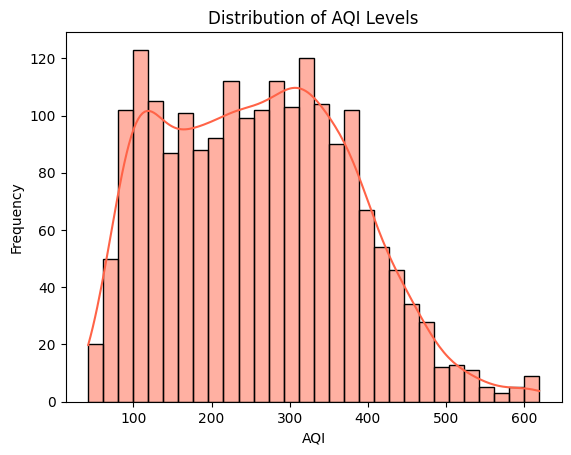

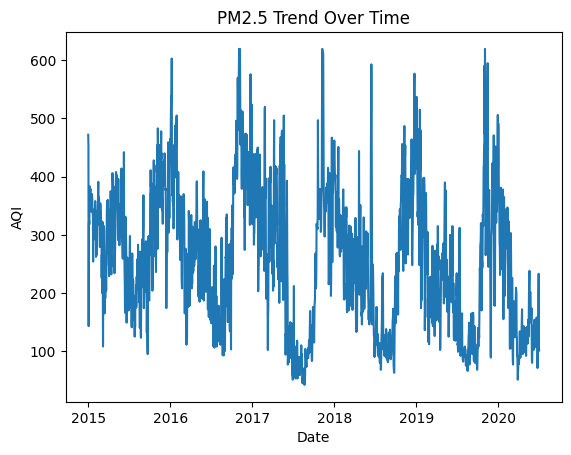

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
# Q1: Distribution of PM2.5
sns.histplot(df_cleaned['AQI'], bins=30, kde=True, color='tomato')
plt.title('Distribution of AQI Levels')
plt.xlabel('AQI')
plt.ylabel('Frequency')
plt.show()

# Q2: PM2.5 trend over time
sns.lineplot(x='Date', y='AQI', data=df_cleaned)
plt.title('PM2.5 Trend Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.show()

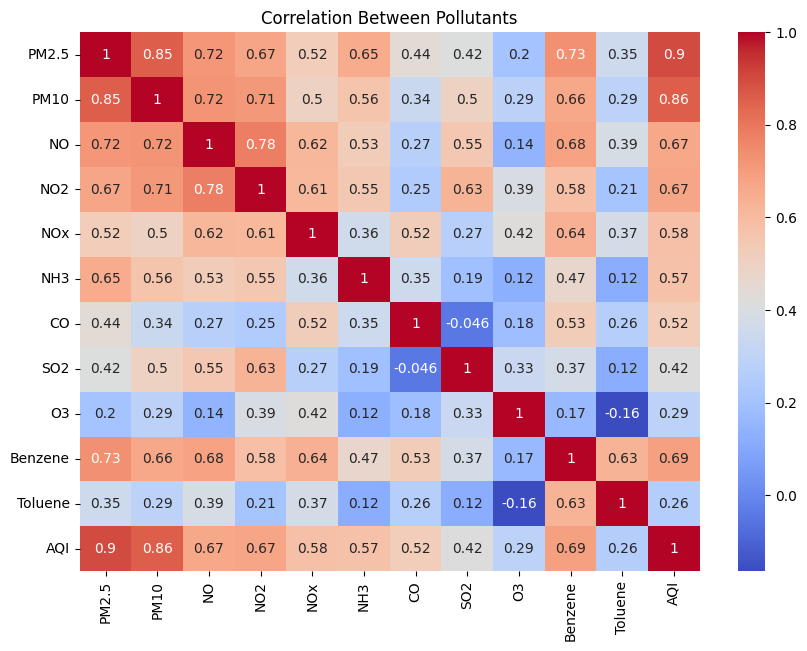

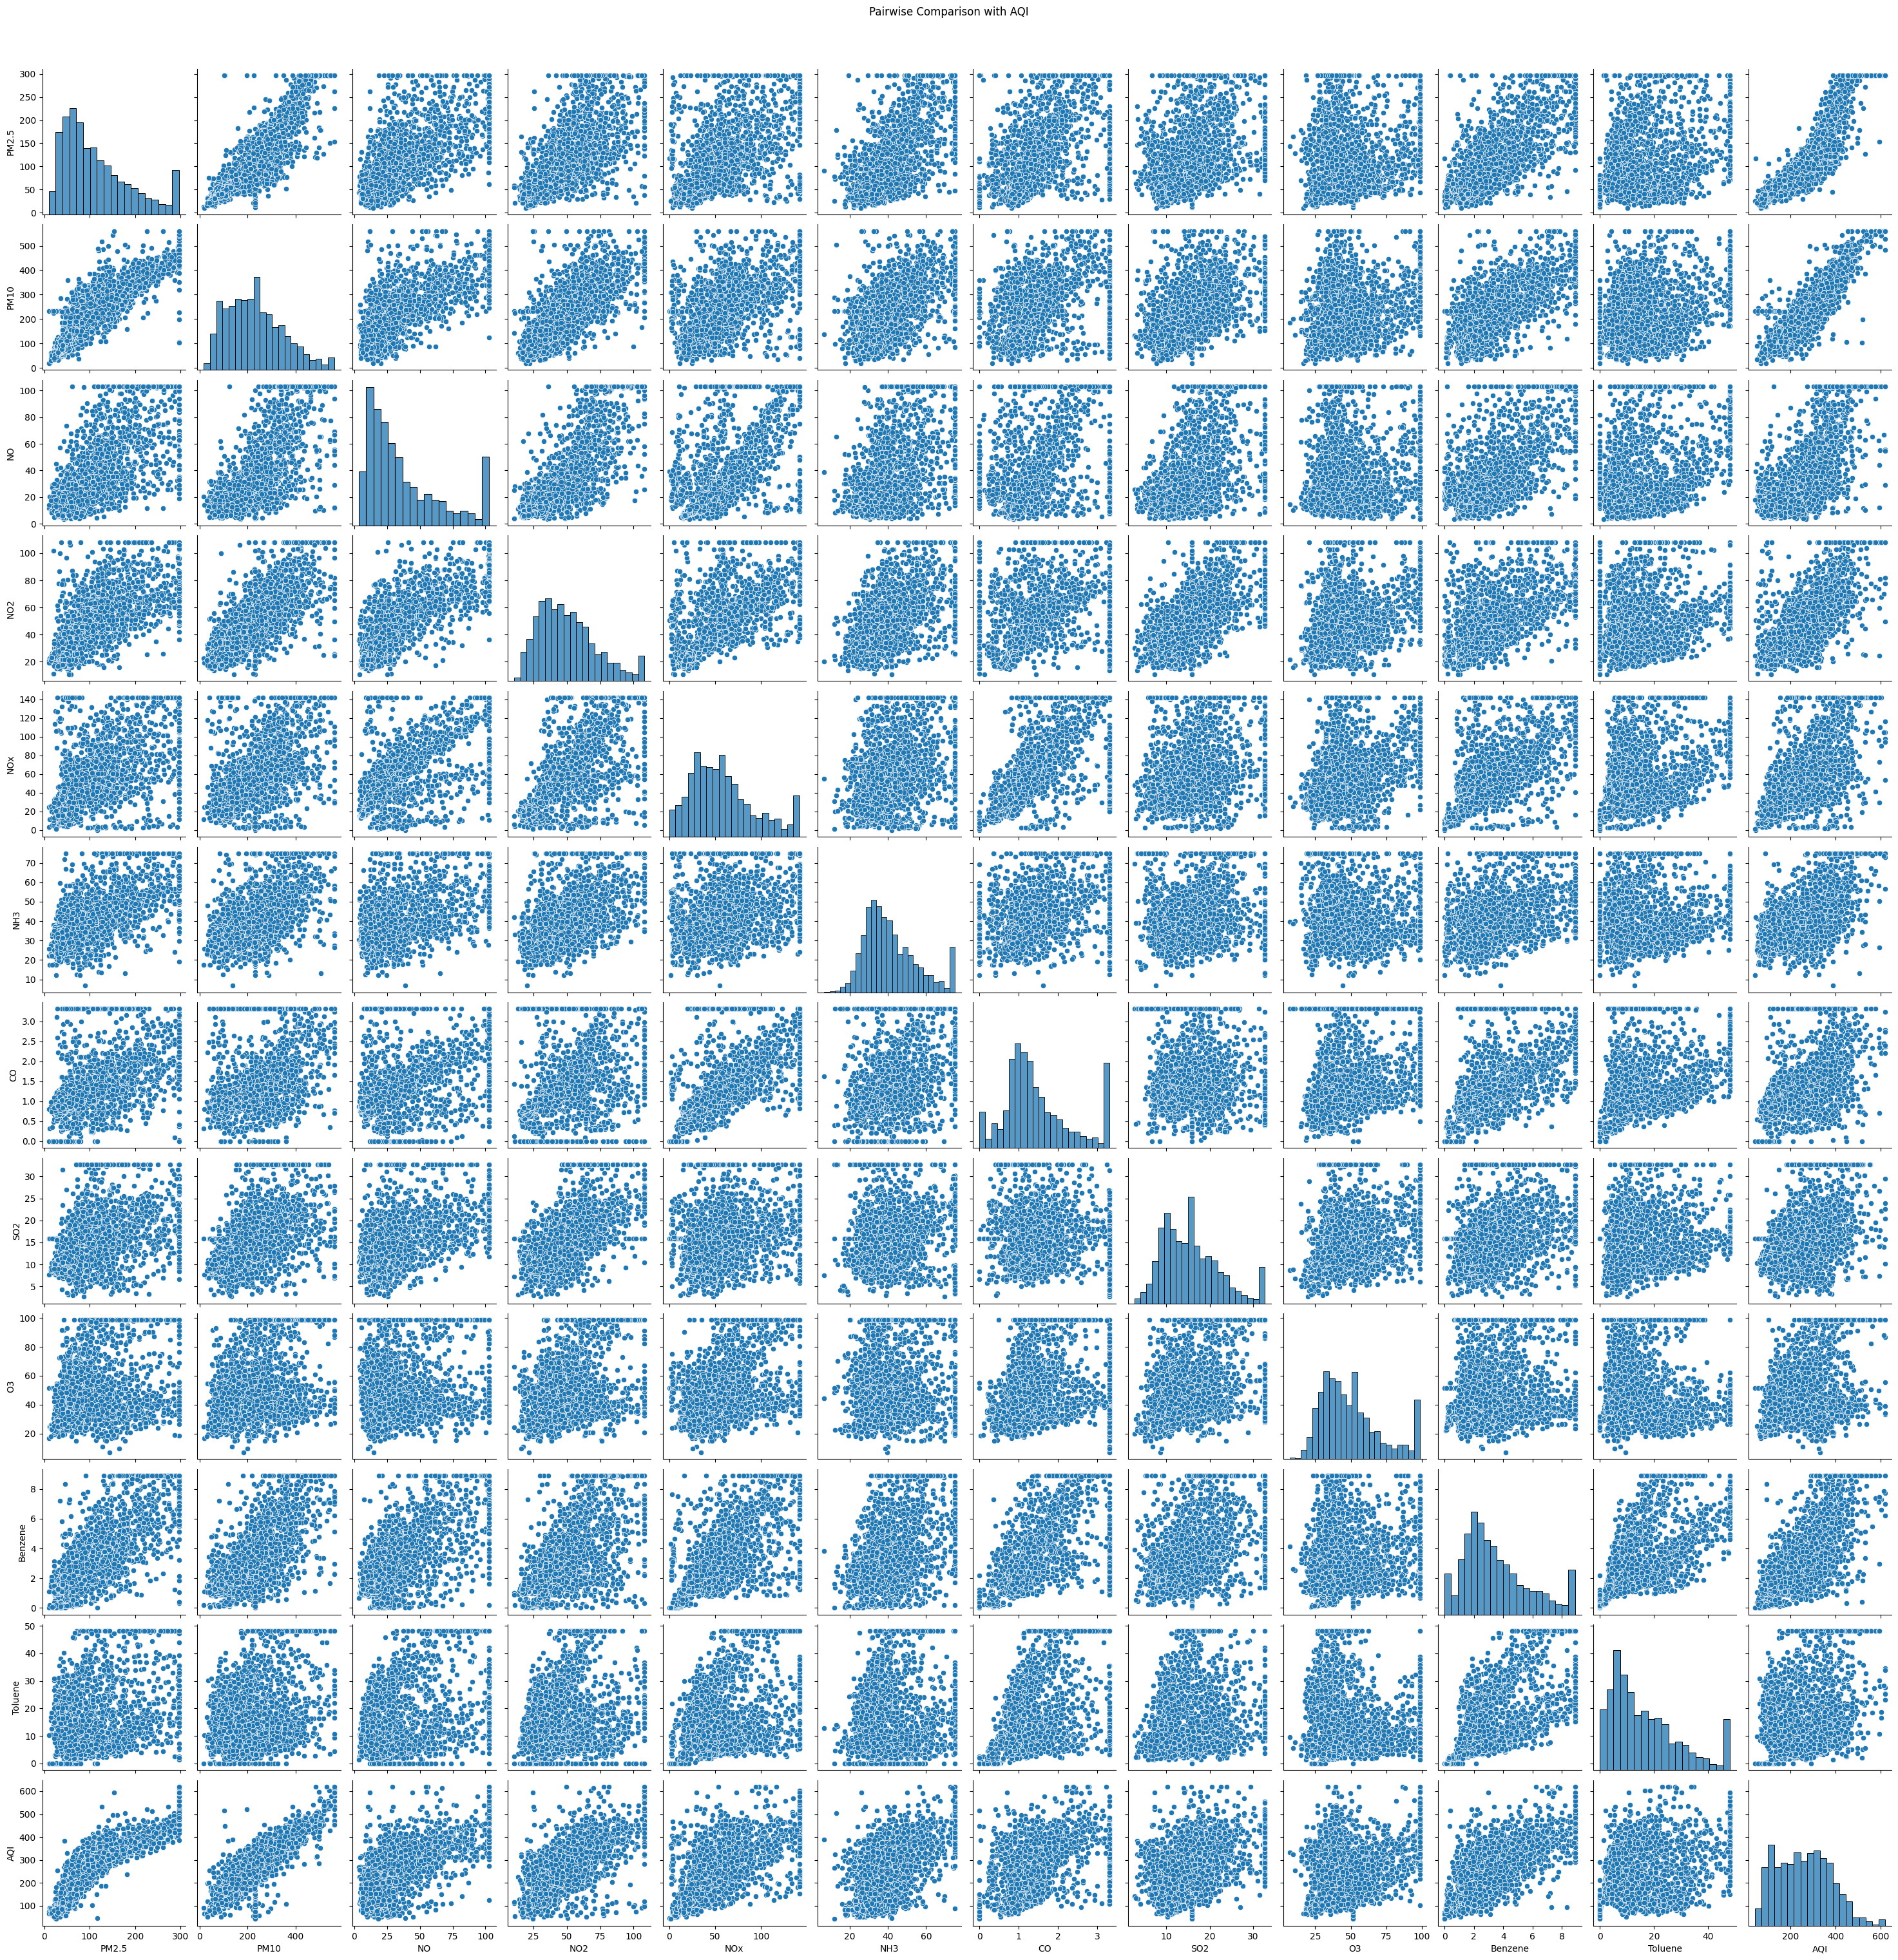

In [ ]:
# Q3: Correlation heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(df_cleaned[['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2',	'O3','Benzene','Toluene','AQI']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Between Pollutants')
plt.show()

# Q4: Pairplot to see PM2.5 vs other pollutants
sns.pairplot(df_cleaned[['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2',	'O3','Benzene','Toluene','AQI']])
plt.suptitle('Pairwise Comparison with AQI', y=1.02)
plt.show()

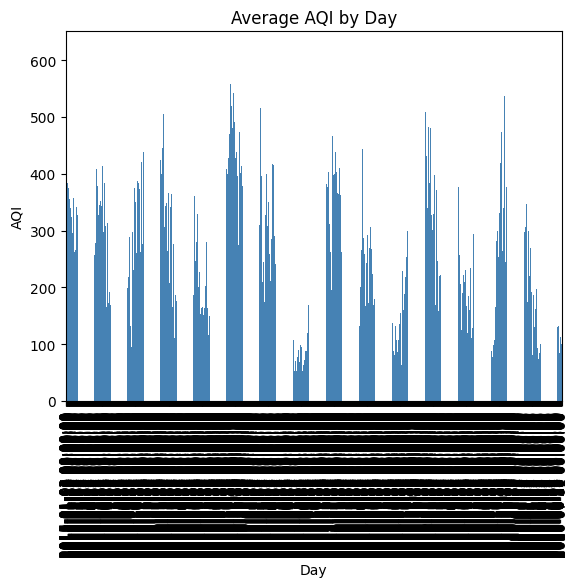

In [ ]:
#df_cleaned['hour'] = df_cleaned['Date'].dt.hour
hourly_avg = df_cleaned.groupby('Date')['AQI'].mean()

hourly_avg.plot(kind='bar', color='steelblue')
plt.title('Average AQI by Day')
plt.xlabel('Day')
plt.ylabel('AQI')
plt.show()

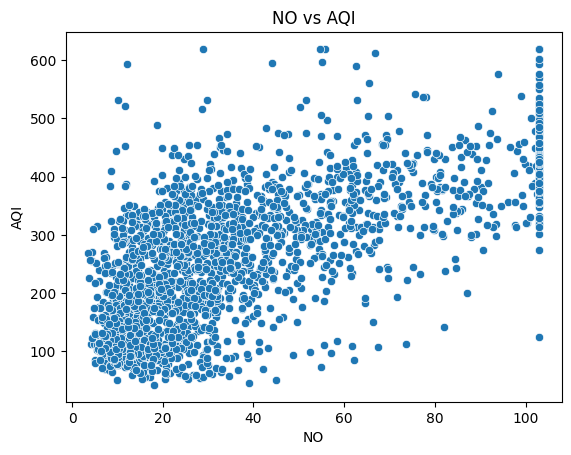

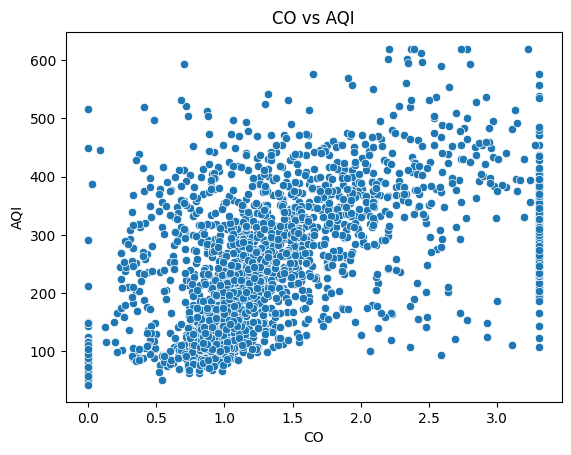

In [ ]:
# Q6: NO2 vs PM2.5
sns.scatterplot(x='NO', y='AQI', data=df_cleaned)
plt.title('NO vs AQI')
plt.show()

# Q7: CO vs PM2.5
sns.scatterplot(x='CO', y='AQI', data=df_cleaned)
plt.title('CO vs AQI')
plt.show()

<Axes: >

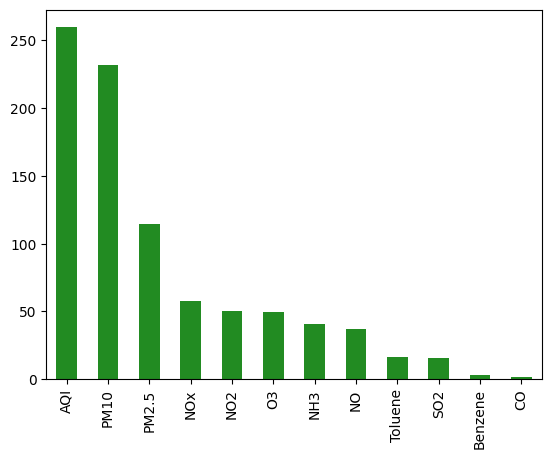

In [ ]:
# Q8: Which pollutant is highest on average?
pollutants = ['PM2.5','PM10','NO','NO2','NOx','NH3','CO','SO2','O3','Benzene','Toluene','AQI']

avg_values = df_cleaned[pollutants].mean().sort_values(ascending=False)

avg_values.plot(kind='bar', color='forestgreen')


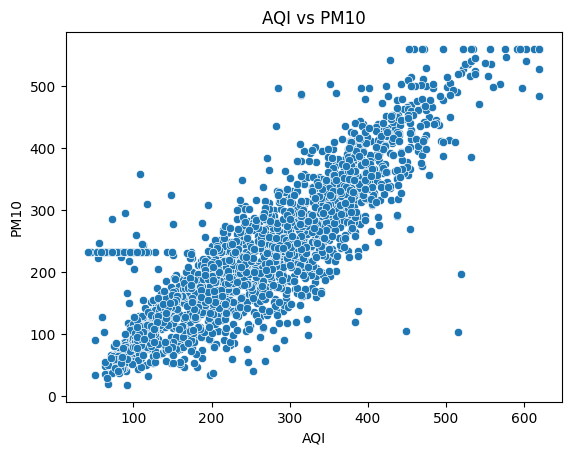

In [ ]:
# Q10: PM2.5 vs PM10
sns.scatterplot(x='AQI', y='PM10', data=df_cleaned)
plt.title('AQI vs PM10')
plt.show()

In [ ]:
# Extract time-based features
df_cleaned['month'] = df_cleaned['Date'].dt.month
df_cleaned['day'] = df_cleaned['Date'].dt.day
df_cleaned['weekday'] = df_cleaned['Date'].dt.weekday  # 0=Monday

# Define features and target
features = ['CO', 'NO', 'NO2', 'O3', 'SO2', 'PM10', 'NH3', 'month', 'day', 'weekday']
target = 'AQI'

X = df_cleaned[features]
y = df_cleaned[target]

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Show feature shapes
print("Training features shape:", X_train.shape)
print("Test features shape:", X_test.shape)

/tmp/ipython-input-3590262875.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['month'] = df_cleaned['Date'].dt.month
/tmp/ipython-input-3590262875.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['day'] = df_cleaned['Date'].dt.day
/tmp/ipython-input-3590262875.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pan

Training features shape: (1599, 10)
Test features shape: (400, 10)


In [ ]:
import numpy as np

In [ ]:
data.set_index('Date',inplace=True)
df=data
df.head()

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket
Date,,,,,,,,,,,,,,
01-01-2015,Delhi,296.825,560.235,69.16,36.39,110.59,33.85,3.31,9.25,41.68,8.895,24.86,472.0,Severe
02-01-2015,Delhi,186.180,269.550,62.09,32.87,88.14,31.83,3.31,6.65,29.97,8.895,20.09,454.0,Severe
03-01-2015,Delhi,87.180,131.900,25.73,30.31,47.95,69.55,3.31,2.65,19.71,3.910,10.23,143.0,Moderate
04-01-2015,Delhi,151.840,241.840,25.01,36.91,48.62,74.87,3.31,4.63,25.36,4.260,9.71,319.0,Very Poor
05-01-2015,Delhi,146.600,219.130,14.01,34.92,38.25,74.87,3.31,3.33,23.20,2.800,6.21,325.0,Very Poor


<Axes: xlabel='Date'>

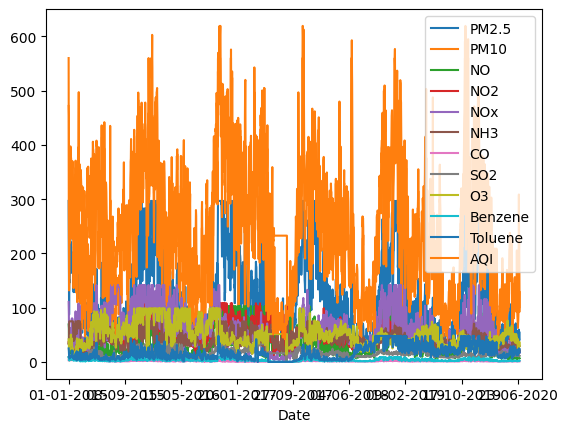

In [ ]:
df.plot()

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
def adfuller_test(context):
  result=adfuller(context)
  labels=['ADF TEST STATISTIC','P-VALUE','#LAGS USED','NUMBER OF OBSERVATIONS USED']
  for value,label in zip(result,labels):
    print(label+' : '+str(value))
  if result[1]<=0.5:
    print("is stationary")
  else:
    print("not stationary")

In [ ]:
adfuller_test(df['AQI'])

ADF TEST STATISTIC : -3.4304407348772337
P-VALUE : 0.009963899553658407
#LAGS USED : 17
NUMBER OF OBSERVATIONS USED : 1991
is stationary


<Axes: xlabel='Date'>

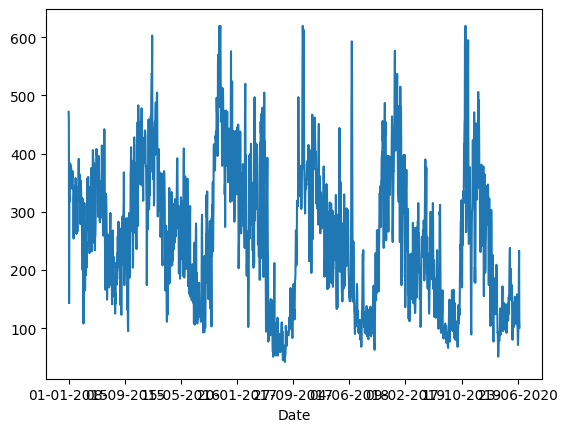

In [ ]:
df["AQI"].plot()

In [ ]:
df['firstdiff']=df['AQI']-df['AQI'].shift(1)           # only is not stationary case
df['seasonalfirstdiff']=df['AQI']-df['AQI'].shift(1)
df.head(24)

,City,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,firstdiff,seasonalfirstdiff
Date,,,,,,,,,,,,,,,,
01-01-2015,Delhi,296.825,560.235,69.16,36.39,110.59,33.85,3.31,9.25,41.68,8.895,24.86,472.0,Severe,NaN,NaN
02-01-2015,Delhi,186.180,269.550,62.09,32.87,88.14,31.83,3.31,6.65,29.97,8.895,20.09,454.0,Severe,-18.0,-18.0
03-01-2015,Delhi,87.180,131.900,25.73,30.31,47.95,69.55,3.31,2.65,19.71,3.910,10.23,143.0,Moderate,-311.0,-311.0
04-01-2015,Delhi,151.840,241.840,25.01,36.91,48.62,74.87,3.31,4.63,25.36,4.260,9.71,319.0,Very Poor,176.0,176.0
05-01-2015,Delhi,146.600,219.130,14.01,34.92,38.25,74.87,3.31,3.33,23.20,2.800,6.21,325.0,Very Poor,6.0,6.0
06-01-2015,Delhi,149.580,252.100,17.21,37.84,42.46,74.87,3.31,3.66,26.83,3.630,7.35,318.0,Very Poor,-7.0,-7.0
07-01-2015,Delhi,217.870,376.510,26.99,40.15,52.41,74.87,3.31,5.82,28.96,4.930,9.42,353.0,Very Poor,35.0,35.0
08-01-2015,Delhi,229.900,360.950,23.34,43.16,51.21,74.87,3.31,3.31,30.51,5.800,11.40,383.0,Very Poor,30.0,30.0
09-01-2015,Delhi,201.660,397.430,19.18,38.56,45.60,74.87,3.31,3.48,32.94,5.250,11.12,375.0,Very Poor,-8.0,-8.0


In [ ]:
adfuller_test(df['seasonalfirstdiff'].dropna()) # only is not stationary case

ADF TEST STATISTIC : -15.695488494872215
P-VALUE : 1.4168269594071573e-28
#LAGS USED : 16
NUMBER OF OBSERVATIONS USED : 1991
is stationary


<Axes: xlabel='Date'>

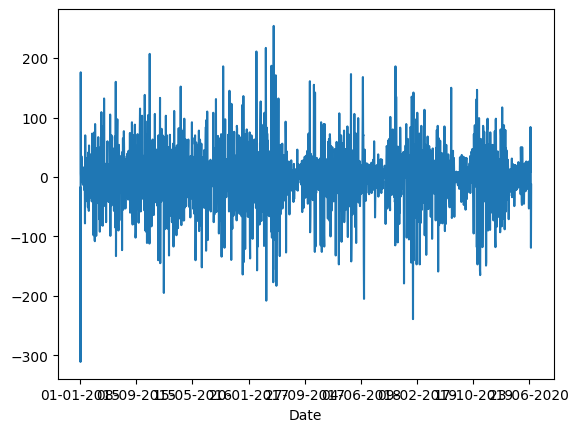

In [ ]:
df['seasonalfirstdiff'].plot()  # only is not stationary case

***Auto regressive model***

In [ ]:
import matplotlib.pyplot as plt

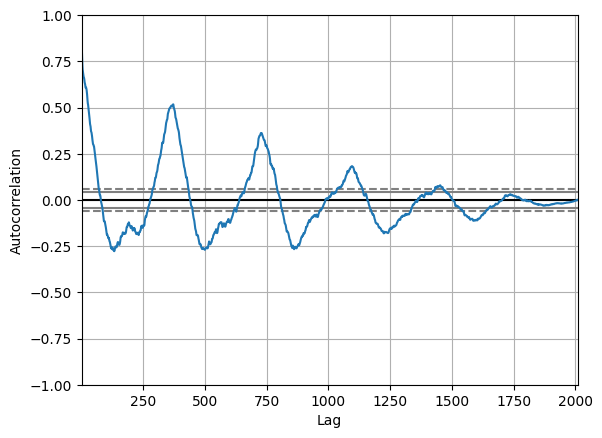

In [ ]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(df['AQI'])
plt.show()

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf

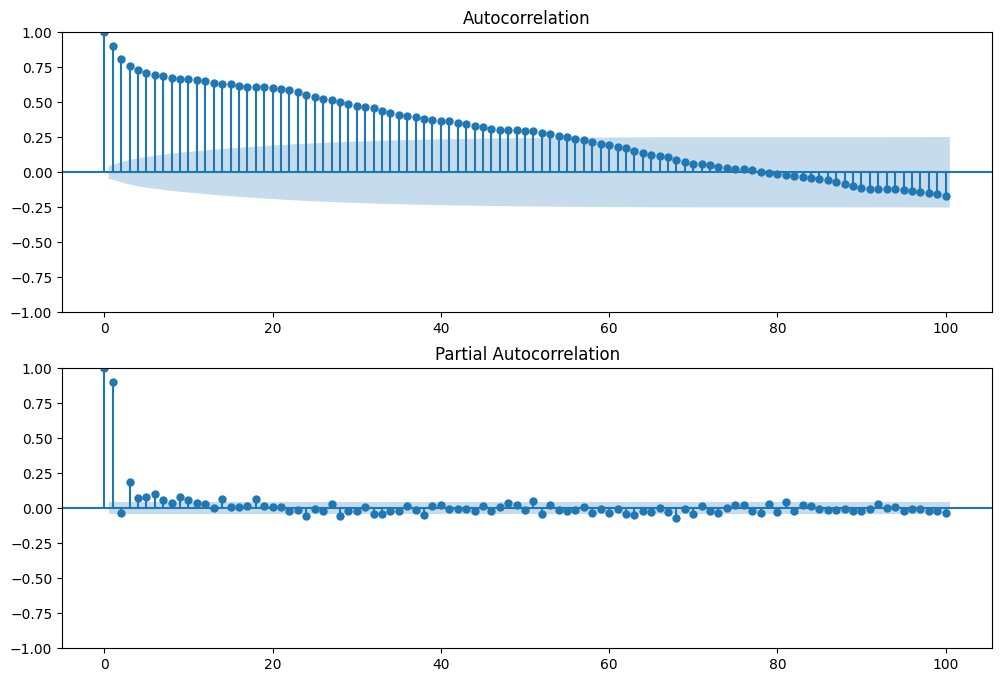

In [ ]:
fig=plt.figure(figsize=(12,8))
ax1=fig.add_subplot(211)
fig=plot_acf(df['AQI'].iloc[25:],lags=100,ax=ax1)
ax2=fig.add_subplot(212)
fig=plot_pacf(df['AQI'].iloc[25:],lags=100,ax=ax2)

In [ ]:
df.to_csv('delhi_exported.csv')


In [ ]:
split_date = '01-12-2019'
len(df['AQI'].loc[:split_date])

1796

In [ ]:
import statsmodels.api as sm

In [ ]:
import statsmodels.api as sm

In [ ]:
split_date = '01-12-2019'
model=sm.tsa.statespace.SARIMAX(df['AQI'].loc[:split_date],order=(1,1,2),seasonal_order=(1,1,2,7))
results=model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)


In [ ]:
a=results.predict(start=2003,end=2009)
a

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


,predicted_mean
2003,250.983154
2004,245.378518
2005,236.945417
2006,234.515938
2007,239.101561
2008,241.990937
2009,243.258937


In [ ]:
df['AQI'].iloc[2003:2009]

,AQI
Date,
26-06-2020,104.0
27-06-2020,112.0
28-06-2020,196.0
29-06-2020,233.0
30-06-2020,114.0
01-07-2020,101.0


In [ ]:
df['forecast']=0

In [ ]:
df['forecast'].iloc[2002:2009] = a
df[['AQI','forecast']].iloc[2002:2009]

/tmp/ipython-input-1788147513.py:1: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  df['forecast'].iloc[2002:2009] = a
/tmp/ipython-input-1788147513.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFra

,AQI,forecast
Date,,
25-06-2020,86.0,250.983154
26-06-2020,104.0,245.378518
27-06-2020,112.0,236.945417
28-06-2020,196.0,234.515938
29-06-2020,233.0,239.101561
30-06-2020,114.0,241.990937
01-07-2020,101.0,243.258937


In [ ]:
print(len(df['forecast'].iloc[2002:2009]))
print(len(a))

7
7


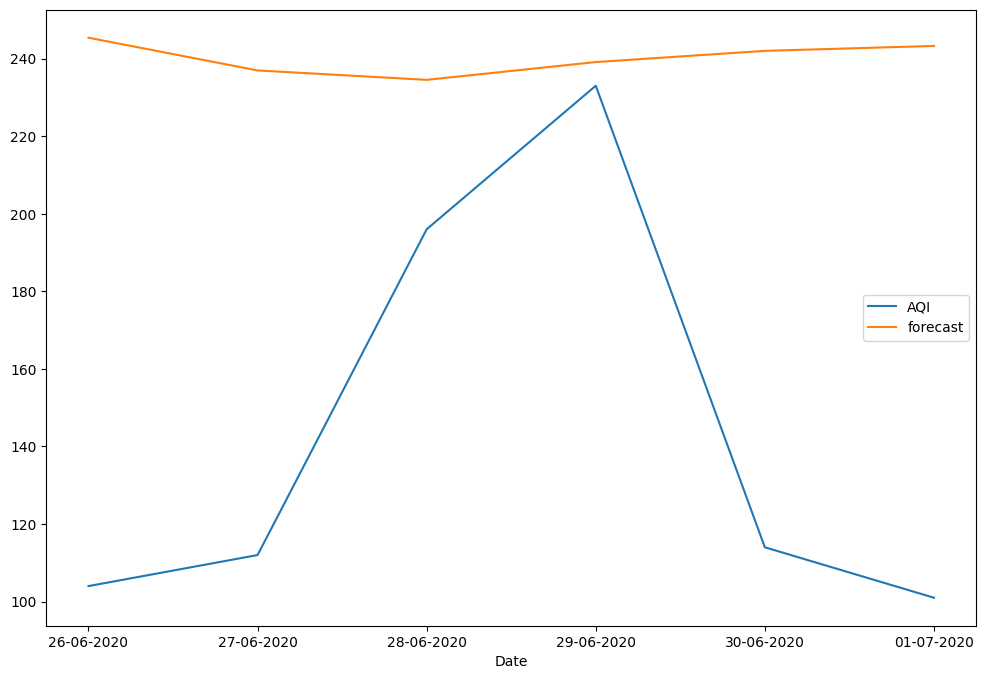

In [ ]:
copm=df[['AQI','forecast']].iloc[2003:2009]
c=copm.plot(figsize=(12,8))

In [ ]:
copm

,AQI,forecast
Date,,
26-06-2020,104.0,245.378518
27-06-2020,112.0,236.945417
28-06-2020,196.0,234.515938
29-06-2020,233.0,239.101561
30-06-2020,114.0,241.990937
01-07-2020,101.0,243.258937


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error,mean_absolute_percentage_error
import numpy as np
mse = mean_squared_error(copm['AQI'], copm['forecast'])
mae = mean_absolute_error(copm['AQI'],copm['forecast'])
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(copm['AQI'], copm['forecast'])
print(mse)
print(mae)
print(rmse)
print(mape)

12289.872398389538
96.86521817307555
110.85969690735014
0.8714869339825585
